# Book Recommendation System – Capstone Project

## Problem Statement

In today's digital world, people have access to millions of books online. However, it is often difficult for readers to find the right book that matches their interests, especially when there are so many choices available. Manually searching or reading through reviews can be time-consuming and confusing. A lot of users miss out on great books simply because they don’t know where to start. This problem becomes even bigger for new readers who have limited reading history. Therefore, there is a need for a smart system that can help users discover books they are likely to enjoy based on their preferences, past behavior, or similar user recommendations. Building such a system will not only make book discovery easier but also improve user satisfaction and encourage more reading. The system should be intelligent, user-friendly, and efficient enough to handle large amounts of data.

Ojective:

To design and build a book recommendation system that helps users find books based on their interests.

To explore and analyze a real-world book dataset for better understanding of user behavior and book trends.

To implement different recommendation techniques such as popularity-based, collaborative filtering, and content-based filtering.

To compare and evaluate different models to find the most effective approach for recommending books.

To build an easy-to-use interface that allows users to interact with the system and get personalized recommendations.

To deploy the system so that it can be accessed by others and used in real-time.

To present the complete process and results as a part of the capstone project report and presentation.

## About the Dataset

Books Dataset – Contains metadata like Book-Title, Author, Publisher, Year, ISBN.

Users Dataset – Includes User-ID, Location, Age.

Ratings Dataset – Includes User-ID, Book-ID (ISBN), and Book-Rating

Over 270,000 book ratings from 90,000+ users

Ratings range from 0 to 10 (implicit and explicit feedback)

Some books have hundreds of ratings, others only a few

In [3]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Collecting

In [6]:
book = pd.read_csv("Books.csv")
rating = pd.read_csv("Ratings.csv")
user = pd.read_csv("Users.csv")

C:\Users\soniv\AppData\Local\Temp\ipykernel_21008\3934456260.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  book = pd.read_csv("Books.csv")


In [7]:
book.head(5)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [10]:
rating.head(5)

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [12]:
user.head(5)

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [14]:
print(book.shape)
print(rating.shape)
print(user.shape)

(271360, 8)
(1149780, 3)
(278858, 3)


# Exploratory Data Analysis

C:\Users\soniv\AppData\Local\Temp\ipykernel_21008\340071400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=book_author, x='Author', y='Count', palette="Set3")


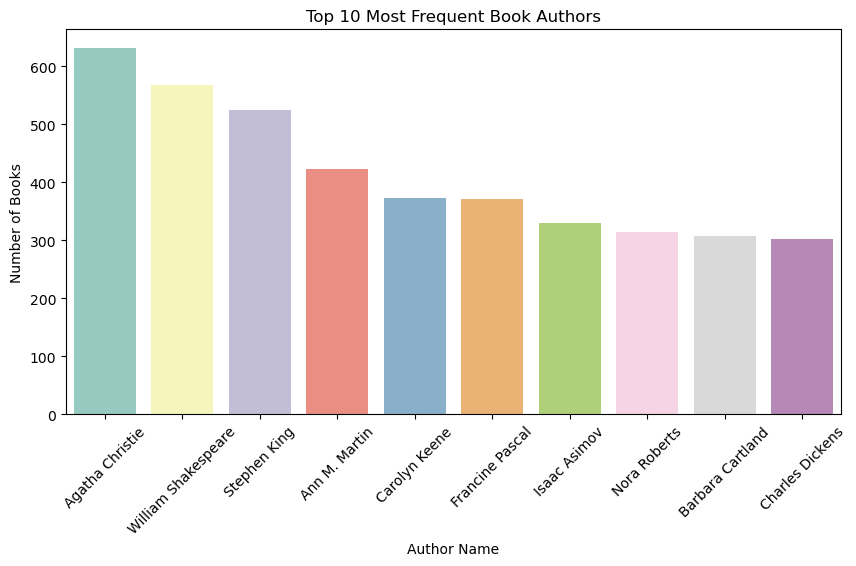

In [17]:
book_author = book["Book-Author"].value_counts().head(10).reset_index()
book_author.columns = ['Author', 'Count']  # Rename columns for clarity
plt.figure(figsize=(10,5))
sns.barplot(data=book_author, x='Author', y='Count', palette="Set3")
plt.xticks(rotation=45)  # Rotate labels for better visibility
plt.title("Top 10 Most Frequent Book Authors")
plt.xlabel("Author Name")
plt.ylabel("Number of Books")
plt.show()

C:\Users\soniv\AppData\Local\Temp\ipykernel_27456\4094049782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(num_book_year, palette="Set3")


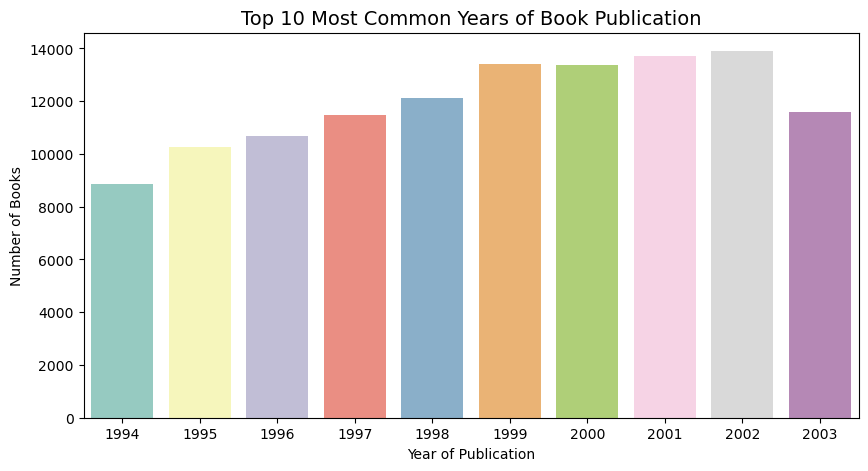

In [89]:
num_book_year = book["Year-Of-Publication"].value_counts().head(10).sort_values(ascending=True)
plt.figure(figsize=(10,5))
sns.barplot(num_book_year, palette="Set3")
plt.title("Top 10 Most Common Years of Book Publication", fontsize=14)
plt.xlabel("Year of Publication")
plt.ylabel("Number of Books")
plt.show()

C:\Users\soniv\AppData\Local\Temp\ipykernel_27456\2374849073.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_publisher, y="Publisher", x="Count", palette="Set2")


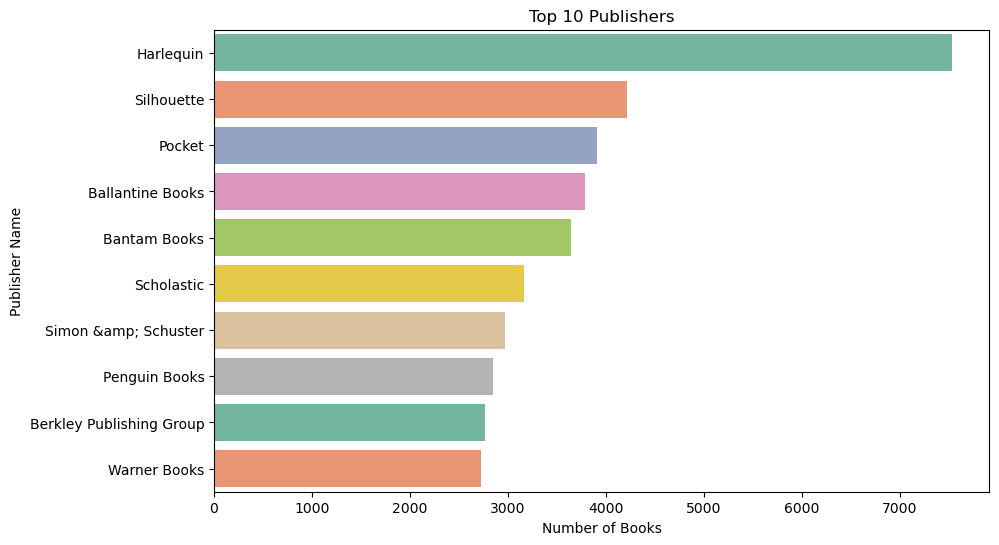

In [92]:
# Get top 10 publishers
top_publisher = book["Publisher"].value_counts().head(10).reset_index()
top_publisher.columns = ["Publisher", "Count"]

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=top_publisher, y="Publisher", x="Count", palette="Set2")
plt.title("Top 10 Publishers")
plt.xlabel("Number of Books")
plt.ylabel("Publisher Name")
plt.show()


In [94]:
print("Unique Book Titles:", book['Book-Title'].nunique())
print("Unique Authors:", book['Book-Author'].nunique())
print("Unique Publishers:", book['Publisher'].nunique())

Unique Book Titles: 242135
Unique Authors: 102022
Unique Publishers: 16807


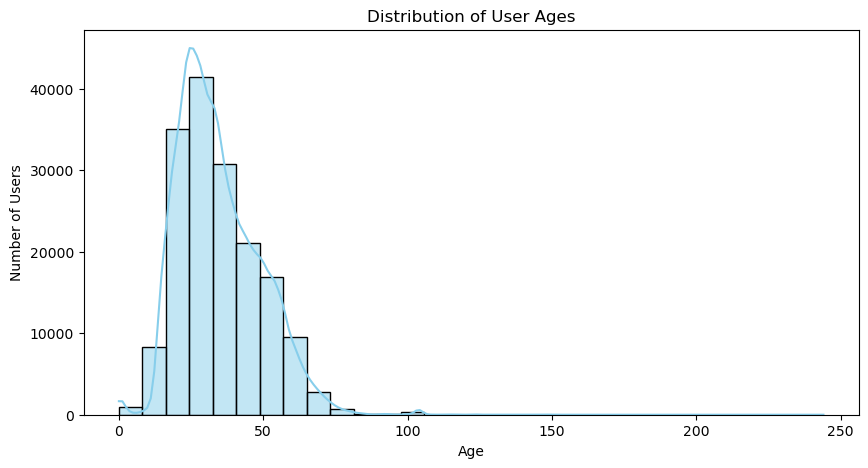

In [96]:
plt.figure(figsize=(10, 5))
sns.histplot(user["Age"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of User Ages")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()


C:\Users\soniv\AppData\Local\Temp\ipykernel_27456\822379024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette="Set3")


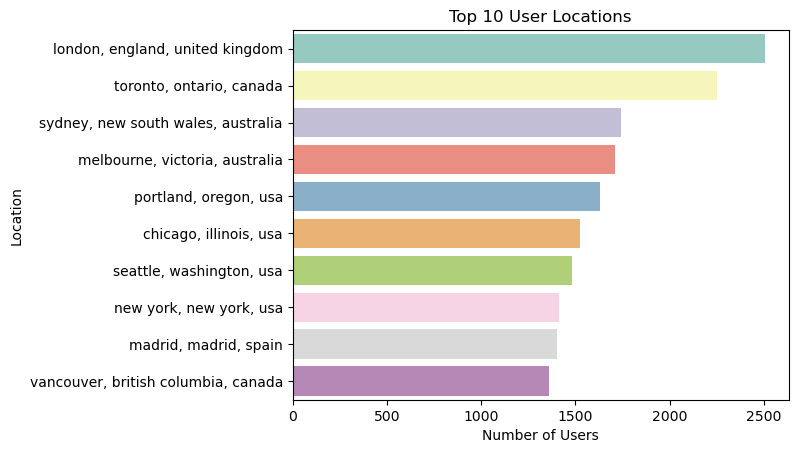

In [97]:
top_locations = user["Location"].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette="Set3")
plt.title("Top 10 User Locations")
plt.xlabel("Number of Users")
plt.ylabel("Location")
plt.show()


In [100]:
print("Total Users:", user["User-ID"].nunique())
print("Average Age of Users:",user["Age"].mean())


Total Users: 278858
Average Age of Users: 34.75143370454978


In [102]:
book.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [104]:
rating.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [106]:
user.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [108]:
book.duplicated().sum()

0

In [109]:
rating.duplicated().sum()

0

In [111]:
user.duplicated().sum()

0

In [113]:
rating.dtypes

User-ID         int64
ISBN           object
Book-Rating     int64
dtype: object

# Popularity Based Recommendation System

In [117]:
rating_with_name = rating.merge(book, on="ISBN")

In [118]:
#Total book rating count
num_rating = rating_with_name.groupby("Book-Title")["Book-Rating"].count().reset_index()

In [119]:
#Rename column  
num_rating.rename(columns={"Book-Rating":"num_rate"},inplace=True)

In [121]:
num_rating

,Book-Title,num_rate
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [125]:
# Each of book Average book rating
avg_rating = rating_with_name.groupby("Book-Title")["Book-Rating"].mean().reset_index()
#Rename column
avg_rating.rename(columns={"Book-Rating":"avg_rating"},inplace=True)

In [126]:
avg_rating

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [127]:
#Merge these Two column 
popularity = num_rating.merge(avg_rating, on="Book-Title")
popularityS

,Book-Title,num_rate,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [131]:
#More than 250 num_rating book 
popularity = popularity[popularity["num_rate"]>=250].sort_values(by="avg_rating", ascending=False).head(50)

In [133]:
#we want image and publisher then merge book
popularity= popularity.merge(book, on="Book-Title").drop_duplicates("Book-Title")

In [135]:
popularity = popularity[["Book-Title","Book-Author", "Image-URL-M", "num_rate","avg_rating"]]

In [137]:
popularity["Image-URL-M"][0]

'http://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'

In [249]:
popularity

,Book-Title,Book-Author,Image-URL-M,num_rate,avg_rating
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0439136350.0...,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,http://images.amazon.com/images/P/0439139597.0...,387,5.824289
5,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/0590353403.0...,278,5.737410
9,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,http://images.amazon.com/images/P/043935806X.0...,347,5.501441
13,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,http://images.amazon.com/images/P/0439064872.0...,556,5.183453
16,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339681.0...,281,5.007117
17,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339703.0...,368,4.948370
26,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,http://images.amazon.com/images/P/059035342X.0...,575,4.895652
28,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339711.0...,260,4.880769
39,To Kill a Mockingbird,Harper Lee,http://images.amazon.com/images/P/0446310786.0...,510,4.700000


# Collaborative Filtering based Recommendatiom System

In [164]:
#UserID Based Filtering
#Count how many ratings each user has given
X = rating_with_name.groupby("User-ID")["Book-Rating"].count()
# Step 2: Extract User-IDs where the count is greater than 200
active_user = X[X>200].index
active_user

Index([   254,   2276,   2766,   2977,   3363,   4017,   4385,   6251,   6323,
         6543,
       ...
       271705, 273979, 274004, 274061, 274301, 274308, 275970, 277427, 277639,
       278418],
      dtype='int64', name='User-ID', length=811)

In [166]:
#This keeps only the rows with User-ID in the active_user list.
filtere_data = rating_with_name[rating_with_name["User-ID"].isin(active_user)]

In [167]:
# Book Title based Filtering
Y = filtere_data.groupby("Book-Title")["Book-Rating"].count()
#This filters the Series to include only books with 50 or more rating
popular_book = Y[Y>=50].index
popular_book 

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Day Late and a Dollar Short', 'A Fine Balance',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='object', name='Book-Title', length=706)

In [168]:
#Only popular books (rated by users 50+ times)
filtere_book_data = filtere_data[filtere_data["Book-Title"].isin(popular_book)]

In [172]:
pivot = filtere_book_data.pivot_table(index="Book-Title",columns="User-ID", values="Book-Rating")
#Fill null value
pivot.fillna(0,inplace=True)

In [174]:
pivot

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Model 

In [177]:
from sklearn.metrics.pairwise import cosine_similarity

In [179]:
similarity_score = cosine_similarity(pivot)

In [181]:
similarity_score.shape

(706, 706)

In [267]:
# Recommend Function
def Recommend(book_name):
    # Find the index of the book
    index = np.where(pivot.index==book_name)[0][0]
     # Find similarity scores and sort
    similar_item = sorted(list(enumerate(similarity_score[index])), key=lambda x:x[1], reverse=True)[1:6]

    data=[]
    for i in similar_item:
        item = []
        temp = book[book["Book-Title"] == pivot.index[i[0]]]
        item.extend(list(temp.drop_duplicates("Book-Title")['Book-Title'].values))
        item.extend(list(temp.drop_duplicates("Book-Title")['Book-Author'].values))
        item.extend(list(temp.drop_duplicates("Book-Title")['Image-URL-M'].values))

        data.append(item)

    return data
        

In [269]:
Recommend("1st to Die: A Novel")

[['Along Came a Spider (Alex Cross Novels)',
  'James Patterson',
  'http://images.amazon.com/images/P/0446364193.01.MZZZZZZZ.jpg'],
 ['Roses Are Red (Alex Cross Novels)',
  'James Patterson',
  'http://images.amazon.com/images/P/0446605484.01.MZZZZZZZ.jpg'],
 ['Pop Goes the Weasel',
  'James Patterson',
  'http://images.amazon.com/images/P/0316693286.01.MZZZZZZZ.jpg'],
 ['Violets Are Blue',
  'James Patterson',
  'http://images.amazon.com/images/P/0446611212.01.MZZZZZZZ.jpg'],
 ['Lightning',
  'Dean R. Koontz',
  'http://images.amazon.com/images/P/0425115801.01.MZZZZZZZ.jpg']]

In [243]:
pivot.index[1]

'1st to Die: A Novel'

# Deployment

In [158]:
#save model and export file 
import pickle 
pickle.dump(popularity,open('popular.pkl','wb'))

In [265]:
pickle.dump(pivot,open('pivot.pkl','wb'))
pickle.dump(book,open('book.pkl','wb'))
pickle.dump(similarity_score,open('similarity_score.pkl','wb'))

In [271]:
df['Book-Title'].value_counts()

Book-Title
Harry Potter and the Prisoner of Azkaban (Book 3)                            1
Left Behind: A Novel of the Earth's Last Days (Left Behind No. 1)            1
Where the Heart Is (Oprah's Book Club (Paperback))                           1
Seabiscuit: An American Legend                                               1
Life of Pi                                                                   1
The Bean Trees                                                               1
A Child Called \It\": One Child's Courage to Survive"                        1
ANGELA'S ASHES                                                               1
Good in Bed                                                                  1
Fast Food Nation: The Dark Side of the All-American Meal                     1
American Gods                                                                1
Skipping Christmas                                                           1
The Golden Compass (His Dark Materials, B

In [ ]:
import pandas as pd            # For data manipulation and analysis
import numpy as np             # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns          # For advanced data visualizations
from sklearn.metrics.pairwise import cosine_similarity  # For similarity calculations
from sklearn.feature_extraction.text import CountVectorizer  # Optional: for text-based similarity
from sklearn.metrics import precision_score, recall_score, f1_score  # For accuracy evaluation
import pickle #save model and export file 